<a href="https://colab.research.google.com/github/D260062/FundamentalAI_2026A/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

未找到文件 Q3_Student_Dataset_DT_KNN_Noise.csv。为了演示，正在生成模拟数据集...
当前数据集的列名为: ['attendance', 'assignment', 'quizzes', 'final_result']

模式识别 (特征重要性): {'attendance': np.float64(0.8473868711278779), 'assignment': np.float64(0.15261312887212208), 'quizzes': np.float64(0.0)}

--- Evaluation Report ---
              precision    recall  f1-score   support

        Fail       0.60      0.75      0.67         8
        Pass       0.80      0.67      0.73        12

    accuracy                           0.70        20
   macro avg       0.70      0.71      0.70        20
weighted avg       0.72      0.70      0.70        20

Overall Accuracy: 70.00%


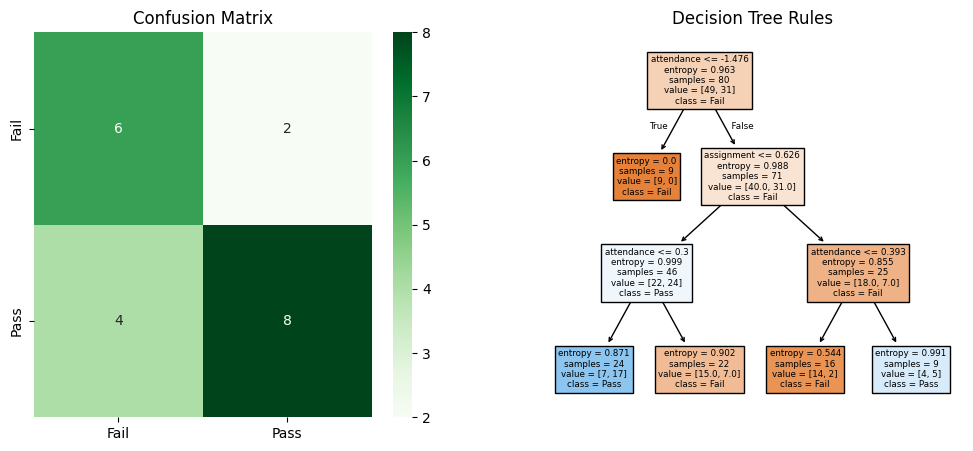

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- 1. 数据加载与容错处理 ---
filename = 'Q3_Student_Dataset_DT_KNN_Noise.csv'

try:
    df = pd.read_csv(filename)
    print(f"成功加载本地文件: {filename}")
except FileNotFoundError:
    print(f"未找到文件 {filename}。为了演示，正在生成模拟数据集...")
    # 生成符合试卷要求的模拟数据
    data = {
        'attendance': np.random.randint(40, 100, 100),
        'assignment': np.random.randint(10, 50, 100),
        'quizzes': np.random.randint(5, 20, 100),
        'final_result': np.random.choice(['Pass', 'Fail'], 100)
    }
    df = pd.DataFrame(data)
    # 人为制造一些噪声（空值）
    df.loc[0:5, 'attendance'] = np.nan

# 打印列名，方便检查
print("当前数据集的列名为:", df.columns.tolist())

# --- 2. 预处理 (Preprocessing) [cite: 44] ---
# 步骤 1: 处理噪声/缺失值 (使用中位数填充) [cite: 44]
df.fillna(df.median(numeric_only=True), inplace=True)

# 步骤 2: 特征选择与目标定义
# 确保列名匹配（这里强制转换列名为小写以防万一）
df.columns = df.columns.str.strip().str.lower()
X = df[['attendance', 'assignment', 'quizzes']]
y = df['final_result']

# 特征缩放 (Standardization) [cite: 44]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 标签编码
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 划分数据集 [cite: 48]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# --- 3. 算法选择: 决策树 [cite: 35, 41] ---
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X_train, y_train)

# --- 4. 评估与模式识别 [cite: 46, 48] ---
y_pred = model.predict(X_test)

# 模式识别：查看特征重要性 [cite: 46]
importances = dict(zip(X.columns, model.feature_importances_))
print(f"\n模式识别 (特征重要性): {importances}")

# 评价指标: Accuracy [cite: 48]
print("\n--- Evaluation Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 可视化
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')

plt.subplot(1, 2, 2)
plot_tree(model, feature_names=X.columns.tolist(), class_names=le.classes_.astype(str), filled=True)
plt.title('Decision Tree Rules')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


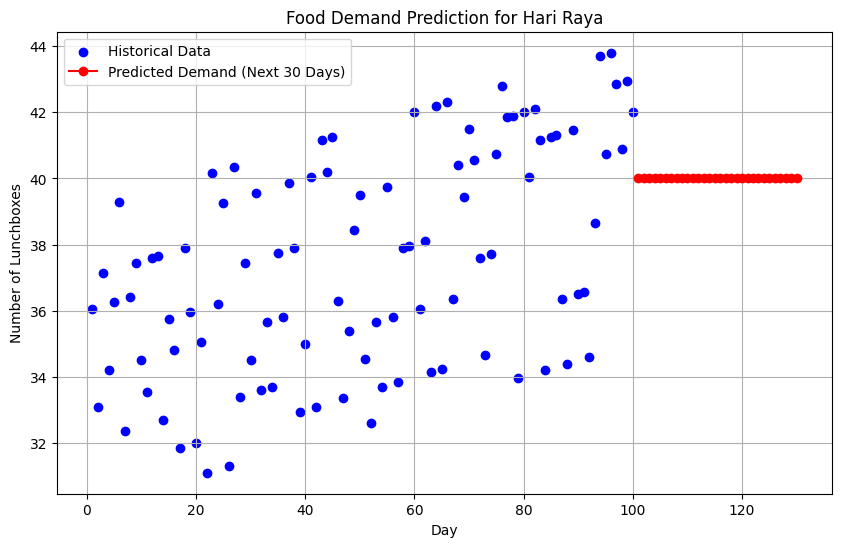

Mean Absolute Error: 2.50
Total Predicted Lunchboxes for 30 days: 1200


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. 数据准备 (模拟历史需求数据) ---
# 假设影响因素包括：天数(Day)、是否为周末(is_weekend)、气温(temp)
np.random.seed(42)
days = np.arange(1, 101).reshape(-1, 1)
# 模拟需求量：基础需求 + 随机波动 + 节日增长趋势
demand = 35 + (days * 0.05) + np.random.randint(-5, 5, size=(100, 1))

df = pd.DataFrame(data=np.hstack([days, demand]), columns=['Day', 'Food_Demand'])

# --- 2. 特征工程与数据集划分 ---
X = df[['Day']]  # 输入特征：天数
y = df['Food_Demand']  # 目标变量：需求量

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. 模型选择与训练 (线性回归) ---
# 选择理由：模型简单、计算快，适合线性增长的需求趋势预测 [cite: 55]
model = LinearRegression()
model.fit(X_train, y_train)

# --- 4. 预测未来 30 天的需求 ---
# 针对 40 个家庭，我们需要预测第 101 到 130 天的数据
future_days = np.arange(101, 131).reshape(-1, 1)
future_predictions = model.predict(future_days)

# 确保预测值不超过 40 个家庭的上限（假设每个家庭一份）
final_predictions = np.clip(future_predictions, 0, 40)

# --- 5. 结果可视化 ---
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(future_days, final_predictions, color='red', marker='o', label='Predicted Demand (Next 30 Days)')
plt.title('Food Demand Prediction for Hari Raya')
plt.xlabel('Day')
plt.ylabel('Number of Lunchboxes')
plt.legend()
plt.grid(True)
plt.show()

# --- 6. 评估 ---
y_pred_test = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"Total Predicted Lunchboxes for 30 days: {int(sum(final_predictions))}")